# Numerical Data Visualization with the Iris Dataset


### Learning Objectives

By the end, you should be able to:
- Understand samples, features, and targets.
- Distinguish numerical and categorical variables.
- Understand univariate, bivariate, and multivariate analysis.
- Choose an appropriate visualization for a question.



# <center> **Data** </center>
Before writing code, learn:<br>
What is my variable type?<br>


                          DATA
                           │
             ┌─────────────┴─────────────┐
             │                           │
      QUALITATIVE                   QUANTITATIVE
      (Categorical)                  (Numerical)
             │                           │
       ┌─────┴─────┐               ┌─────┴─────┐
       │           │               │           │
    NOMINAL     ORDINAL         DISCRETE   CONTINUOUS
       │           │               │           │
    No order     Has order       Count       Measure

## 1. What Is Data Visualization?

**Data visualization** means representing data graphically so that patterns, distributions, relationships, differences, and unusual observations become easier to see.

Raw numbers are important, but a table can make patterns difficult to notice. A graph can reveal a relationship almost immediately.

For example, if we have employee data:

| Age | Salary |
|---:|---:|
| 22 | 30000 |
| 25 | 35000 |
| 28 | 42000 |
| 31 | 50000 |
| 35 | 59000 |

A scatter plot lets us quickly inspect whether salary tends to increase as age increases.

### Why visualize before machine learning?

Visualization can help us discover:
- missing values
- unusual observations/outliers
- distributions and spread
- relationships between features
- correlations
- class imbalance
- possible class separation


Visualization is part of **Exploratory Data Analysis (EDA)**.


In [63]:
import matplotlib.pyplot as plt

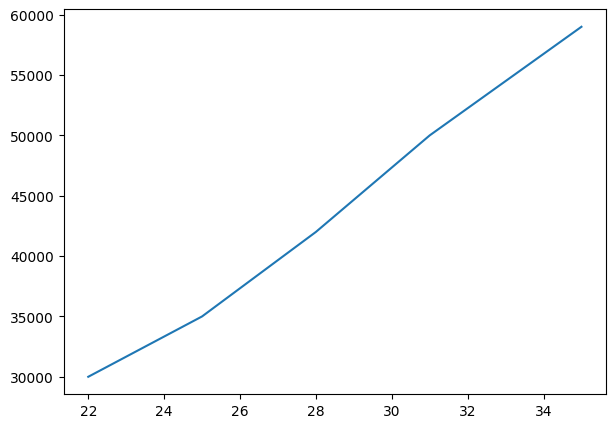

In [64]:
age = [22, 25, 28, 31, 35]
salary = [30000, 35000, 42000, 50000, 59000]

plt.figure(figsize=(7,5))
plt.plot(age, salary)
plt.show()


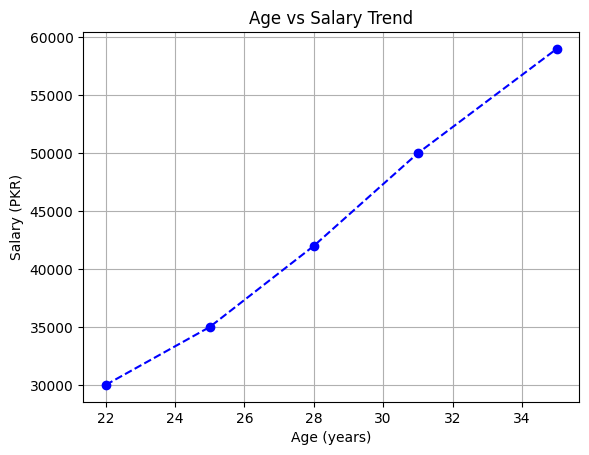

In [65]:
plt.plot(age, salary, marker="o", linestyle="--", color="b") 
plt.title("Age vs Salary Trend") 
plt.xlabel("Age (years)") 
plt.ylabel("Salary (PKR)")
plt.grid(True) 
plt.show()

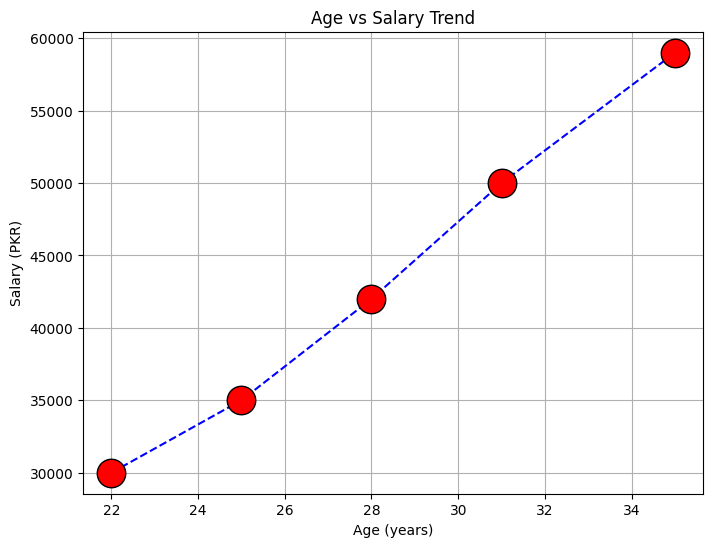

In [66]:
plt.figure(figsize=(8,6))
# marker = 's'->Square, '*', '.', 'o'->Circle
# markersize(ms) = 10.5
# linestyle(ls)  ,  dotted-> :  , dashed-> --.    
# color(c),  ='red', 'green', 'blue'
# linewidth(ls) 
# markerfacecolor (mfc)
# markeredgecolor (mec)  
plt.plot(age, salary, marker="o", linestyle="--", color="b", ms=20.5, markerfacecolor='red', markeredgecolor='black') 
plt.title("Age vs Salary Trend") # loc='left,center(default),right'
plt.xlabel("Age (years)", ) # c, loc, size
plt.ylabel("Salary (PKR)")
plt.grid(True) # axis=both(default, 'x', 'y')
plt.show()


## 2. Understanding the Iris Dataset

The Iris dataset is a classic educational dataset containing measurements of iris flowers.

- **150 samples/observations**
- **4 numerical input features**
- **1 categorical target**
- **3 classes/species**
- Each row represents one flower.
- Each feature is a measurement used as an input.

### Features

1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

### Target classes

- Setosa
- Versicolor
- Virginica

Think of the dataset as:

**Rows → samples**

**Columns → features + target**

**Features → measurements used as input**

**Target → species we want to distinguish**


In [67]:
# 3. Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


## 3. Load the Dataset



In [68]:
iris = load_iris()

print("Object type:", type(iris))
print("Available attributes:")
print(iris.keys()) # attributes/public variable of load_iris class which can now access by iris object.


Object type: <class 'sklearn.utils._bunch.Bunch'>
Available attributes:
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [69]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [70]:
print("Data shape:", iris.data.shape)

Data shape: (150, 4)


In [71]:

print("Feature names:", iris.feature_names)


Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [72]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [73]:
print("Target names:", iris.target_names)

Target names: ['setosa' 'versicolor' 'virginica']


## 4. Convert to a Pandas DataFrame

- df is a tabular structure in pd
- to apply all the d/f kinds of method on the data we need to create an object of pd


In [74]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

In [75]:
print(iris.target_names[0])

setosa


In [76]:
print(iris.target_names[1])

versicolor


In [77]:
iris.target_names[2]

np.str_('virginica')

In [78]:
iris.target_names[iris.target] #  iris.target act as indix here

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [79]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [80]:
# Lets add target column to the dataframe object
df["species"] = iris.target_names[iris.target]



In [81]:
# Lets see top elements of df, by default head() function show first top  record.
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [82]:
df.head(8)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa


In [83]:
# it shows last 5 record by default
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [84]:
df.tail(7)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
143,6.8,3.2,5.9,2.3,virginica
144,6.7,3.3,5.7,2.5,virginica
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [85]:
df.sample()  # sh 1.

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
76,6.8,2.8,4.8,1.4,versicolor


In [86]:
# Let's see some random 10 rows/records/sample/tuple/obseravation/datapoint/instance
df.sample(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
146,6.3,2.5,5.0,1.9,virginica
35,5.0,3.2,1.2,0.2,setosa
21,5.1,3.7,1.5,0.4,setosa
49,5.0,3.3,1.4,0.2,setosa
75,6.6,3.0,4.4,1.4,versicolor
52,6.9,3.1,4.9,1.5,versicolor
133,6.3,2.8,5.1,1.5,virginica
37,4.9,3.6,1.4,0.1,setosa
44,5.1,3.8,1.9,0.4,setosa
14,5.8,4.0,1.2,0.2,setosa


<!-- ## 5. First Dataset Inspection

Before plotting, inspect the dataset systematically.

### Important commands

- `shape` → dimensions
- `columns` → column names
- `info()` → data types and non-null counts
- `describe()` → numerical summary statistics
- `isnull().sum()` → missing-value count
- `value_counts()` → category frequencies -->


In [87]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

# Part A — Univariate Analysis

## 1. Histogram
**How is one numerical feature distributed?**

### Def 
A histogram divides numerical values into **bins** and shows how many observations fall into each bin.

It helps us inspect:
- center
- spread
- shape
- skewness
- possible multiple peaks
- unusual values/outliers

### So
- X-axis → feature values
- Y-axis → count/frequency
- Each bar → number of observations in a value interval


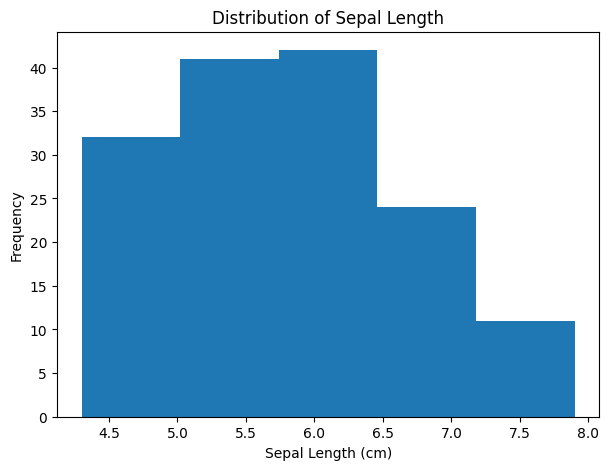

In [88]:
plt.figure(figsize=(7,5))
plt.hist(df['sepal length (cm)'], bins=5)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')
plt.title('Distribution of Sepal Length')

plt.show()

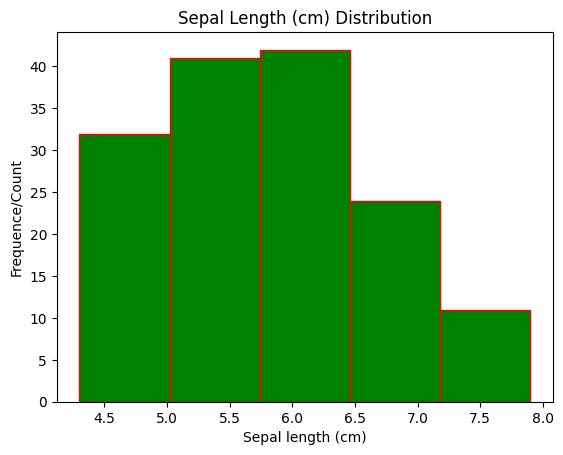

In [89]:
plt.hist(df['sepal length (cm)'],
        bins=5,
        color='green',
        edgecolor='red')

plt.title('Sepal Length (cm) Distribution')
plt.xlabel('Sepal length (cm)')
plt.ylabel('Frequence/Count')
plt.show()

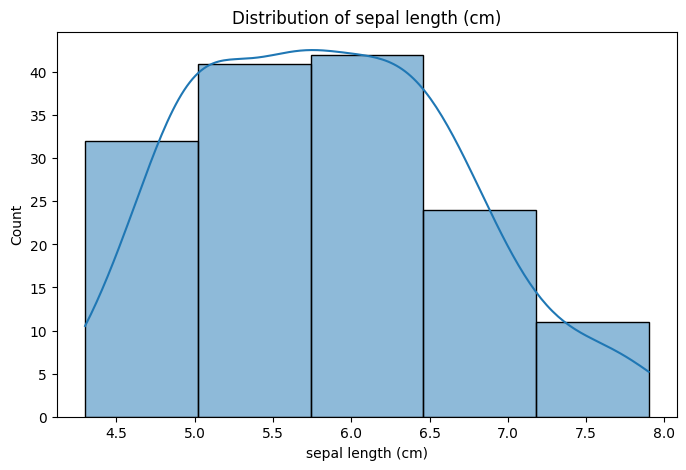

In [90]:
feature = "sepal length (cm)"

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x=feature, bins=5, kde=True)
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.show()




**Note** A distribution can motivate later decisions such as scaling, transformation, or investigating unusual observations.

**Limitation:** A histogram does not show relationships between two features or prove that one variable causes another.


In [91]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

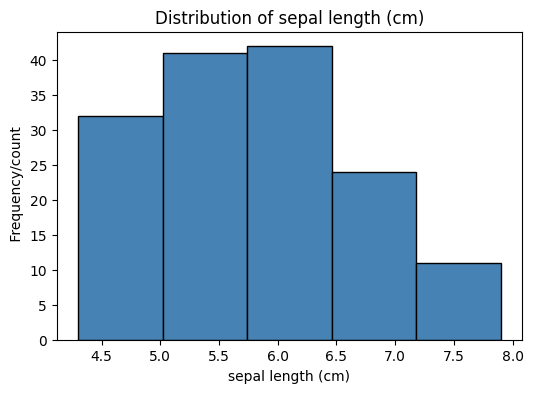

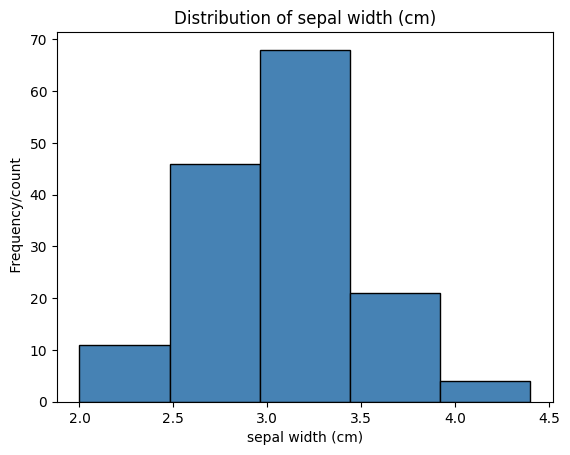

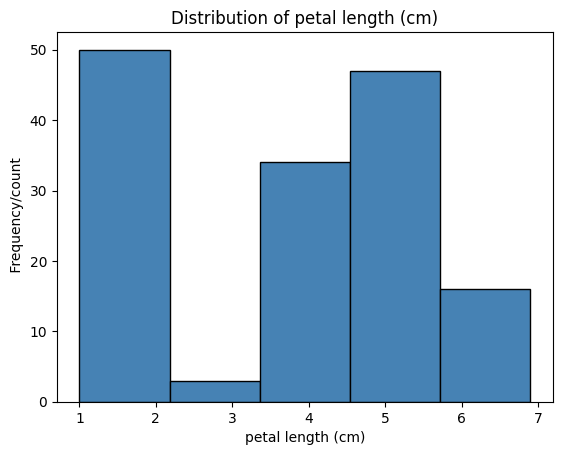

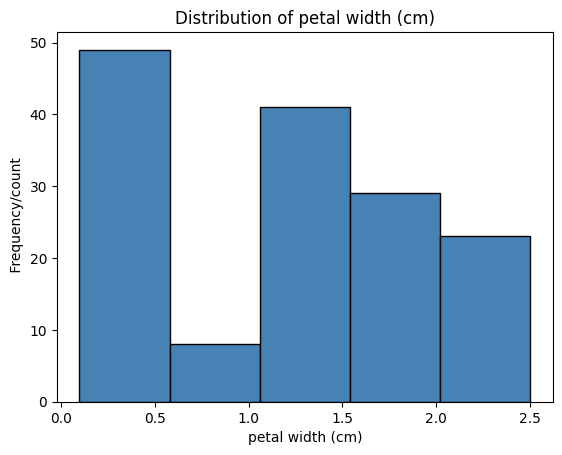

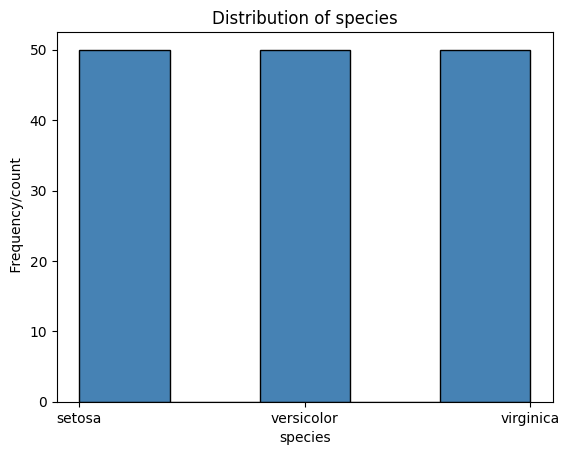

In [92]:
plt.figure(figsize=(6,4))
for column in df.columns:
    plt.hist(df[column],
            bins=5,
            color='steelblue',
            edgecolor='black')
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel(f" Frequency/count")
    plt.show()

## 2. KDE Plot

**Kernel Density Estimation (KDE)** produces a smooth estimate of a numerical variable's distribution.
A KDE is an estimate, not a list of raw counts.


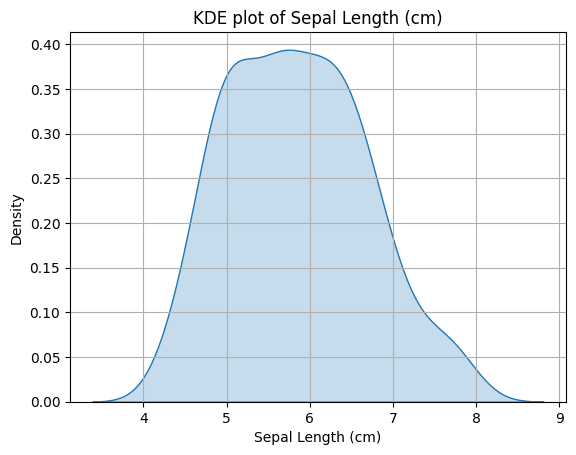

In [93]:
sns.kdeplot(df['sepal length (cm)'], fill=True, )
plt.title("KDE plot of Sepal Length (cm)")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Density")
plt.grid(axis="both")
plt.show()

In [94]:
numerical_columns = df.select_dtypes(exclude="O")
numerical_columns

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


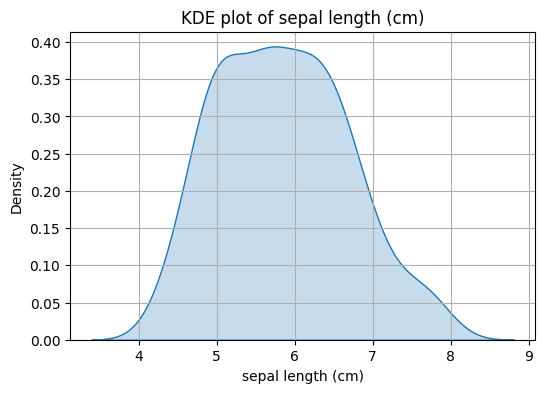

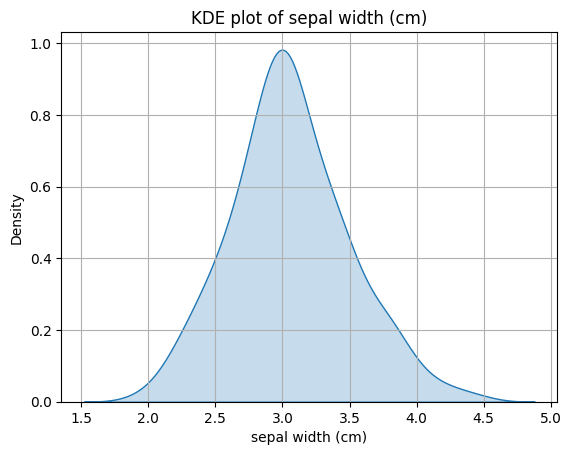

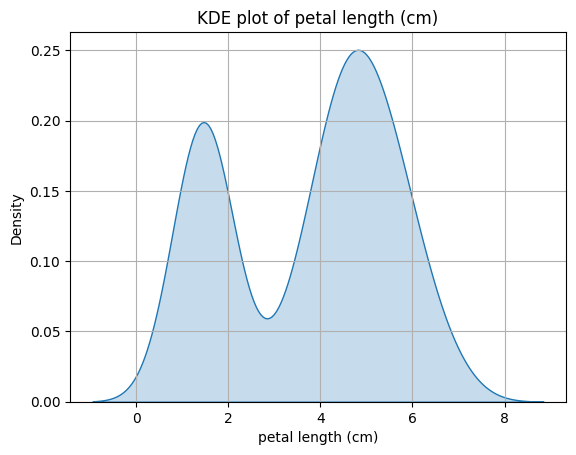

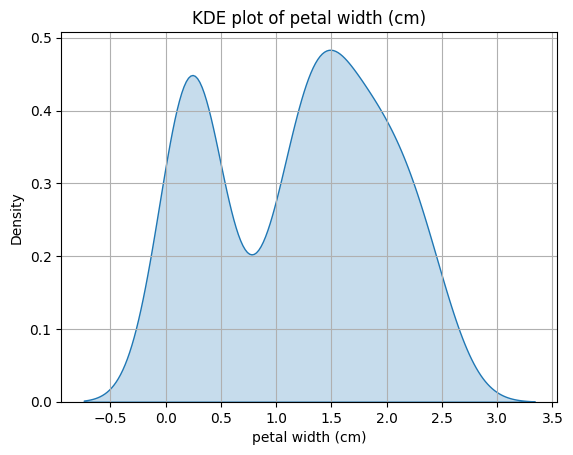

In [95]:
# Seperate the numerical features from the dataframe
numerical_columns = df.select_dtypes(exclude="O")

plt.figure(figsize=(6,4))
for column in numerical_columns:
    sns.kdeplot(df[column], fill=True)
    plt.title(f"KDE plot of {column}")
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.grid()
    plt.show()


In [96]:
# fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# axes = axes.ravel()

# for ax, feature in zip(axes, numerical_features):
#     sns.kdeplot(data=df, x=feature, fill=True, ax=ax)
#     ax.set_title(f"KDE of {feature}")

# plt.tight_layout()
# plt.show()


## 3. Box Plot
**What is the center, spread, and possible outliers of a numerical variable?**

A box plot summarizes a distribution using quartiles.

- Q1 → 25th percentile
- Median → 50th percentile
- Q3 → 75th percentile
- IQR → `Q3 - Q1`
- Whiskers → extend to values within the plot's whisker rule
- Points beyond the whiskers → potential outliers

A box plot is especially useful for **comparing distributions across groups**.


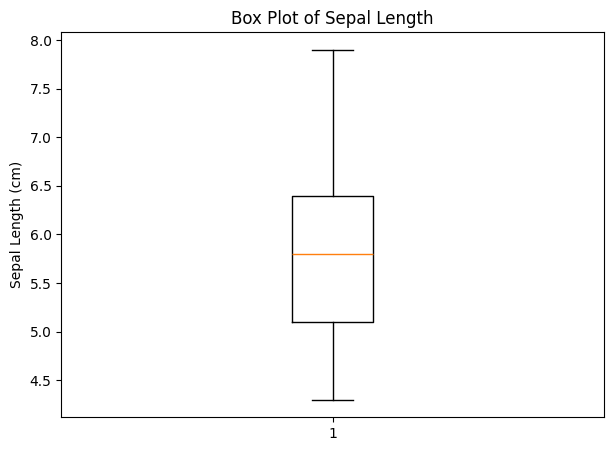

In [97]:

plt.figure(figsize=(7,5))
plt.boxplot(df['sepal length (cm)'])

plt.ylabel('Sepal Length (cm)')
plt.title('Box Plot of Sepal Length')
plt.show()


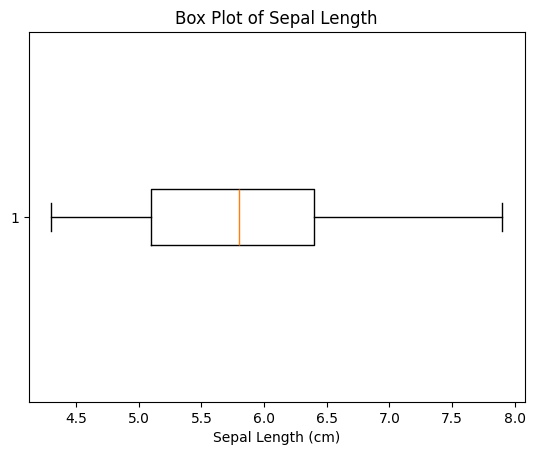

In [98]:
plt.boxplot(df['sepal length (cm)'], vert=False)

plt.xlabel('Sepal Length (cm)')
plt.title('Box Plot of Sepal Length')

plt.show()

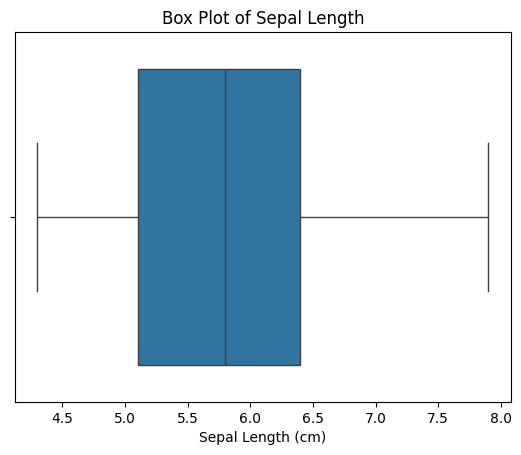

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['sepal length (cm)'])

plt.xlabel('Sepal Length (cm)')
plt.title('Box Plot of Sepal Length')

plt.show()

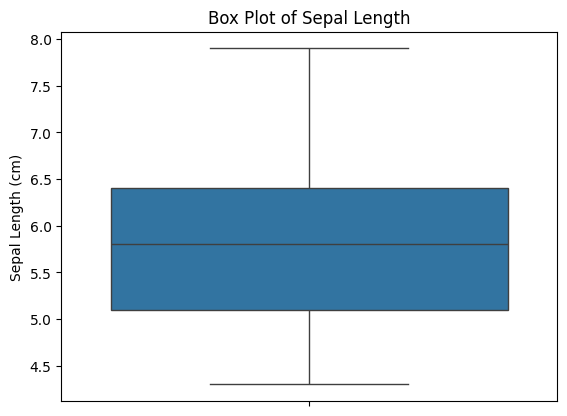

In [100]:
sns.boxplot(y=df['sepal length (cm)'])

plt.ylabel('Sepal Length (cm)')
plt.title('Box Plot of Sepal Length')

plt.show()

In [105]:
numerical_features = iris.feature_names
numerical_features

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

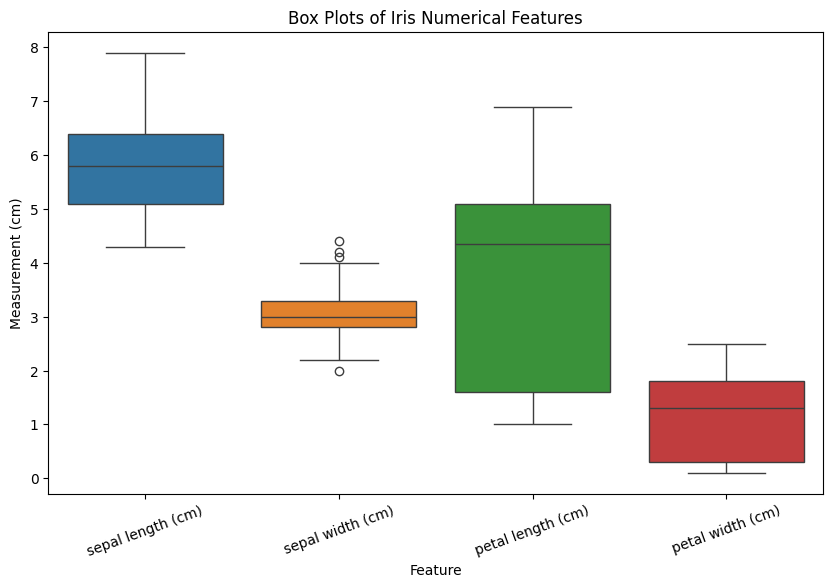

In [106]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numerical_features])
plt.title("Box Plots of Iris Numerical Features")
plt.xlabel("Feature")
plt.ylabel("Measurement (cm)")
plt.xticks(rotation=20)
plt.show()


### Important distinction

A point shown as a box-plot outlier is an **unusual observation according to the box-plot rule**. It is not automatically a bad data point.

Always investigate before deleting observations.


## 4. Box Plot by Species


**How does a numerical feature differ across species?**

Here `species` is categorical, so it is useful on the X-axis. The numerical measurement goes on the Y-axis.


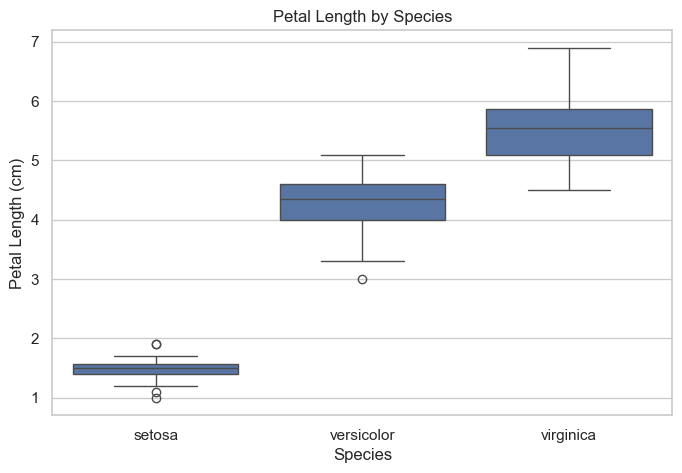

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="species", y="petal length (cm)")
plt.title("Petal Length by Species")
plt.xlabel("Species")
plt.ylabel("Petal Length (cm)")
plt.show()


In [117]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [119]:
features = iris.feature_names
features

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

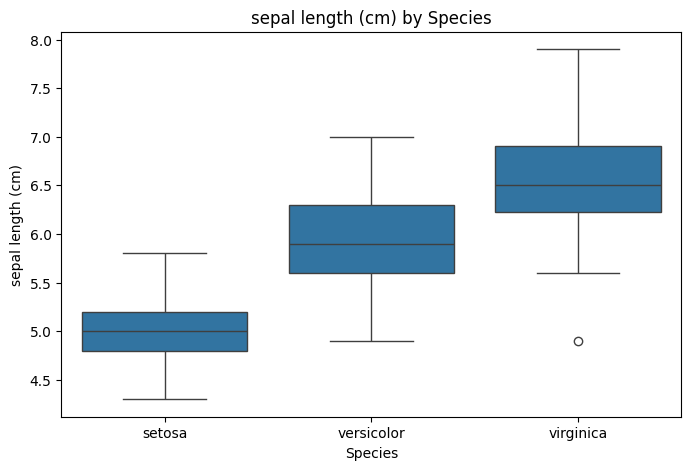

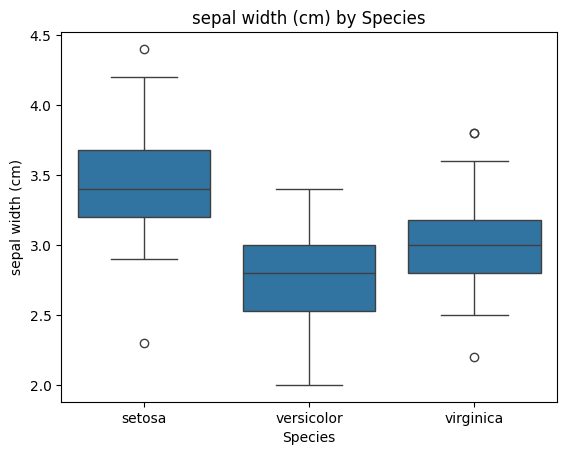

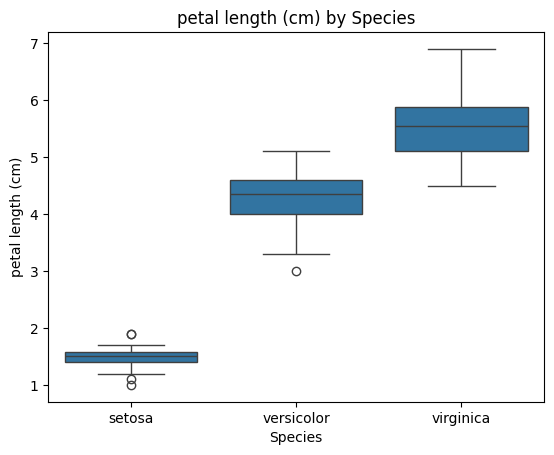

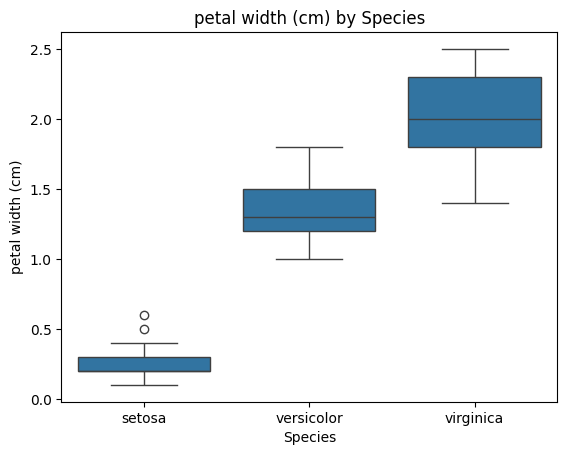

In [120]:

plt.figure(figsize=(8, 5))

for column in features:
    sns.boxplot(data=df, x="species", y=column)
    plt.title(f"{column} by Species")
    plt.xlabel("Species")
    plt.ylabel(column)
    plt.show()

## 5. Count Plot

### Question
**How many observations belong to each category?**

A count plot is appropriate for categorical variables.

The bar height represents the number of observations in that category.


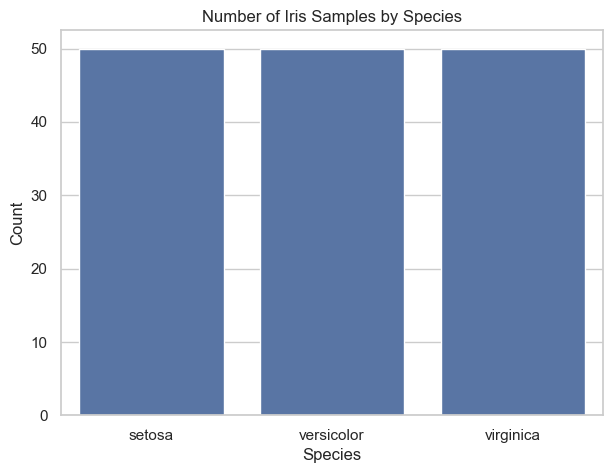

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="species")
plt.title("Number of Iris Samples by Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()


The three species have equal numbers of observations in the standard Iris dataset.

### Why not use a histogram?

A histogram is designed for **numerical values divided into intervals**. `species` is categorical, so a count plot is the natural choice.


# Part B — Bivariate Analysis

## 6. Scatter Plot

### Question
**Do two numerical variables appear to have a relationship?**

Each point represents one flower.

- X-axis → first feature
- Y-axis → second feature
- Point position → that flower's two measurements

Look for:
- positive relationship
- negative relationship
- no obvious relationship
- clusters
- outliers
- nonlinear patterns


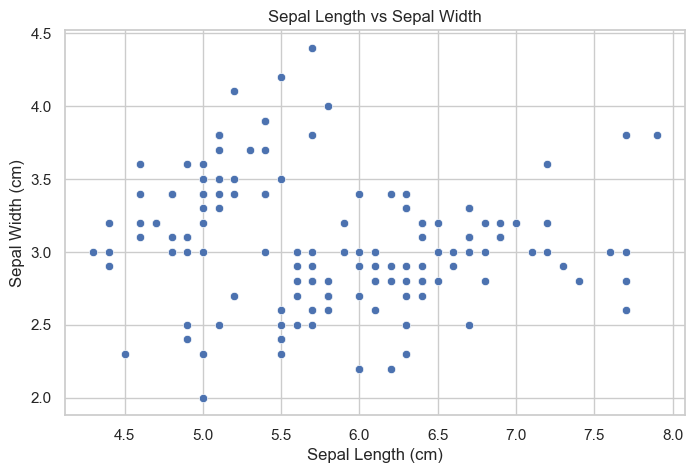

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)"
)
plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.show()


## 7. Scatter Plot Colored by Species

Adding color gives us a third variable.

**X-axis → Feature 1**

**Y-axis → Feature 2**

**Color → Species**

This is especially useful when the target is categorical and we want to investigate visual class separation.


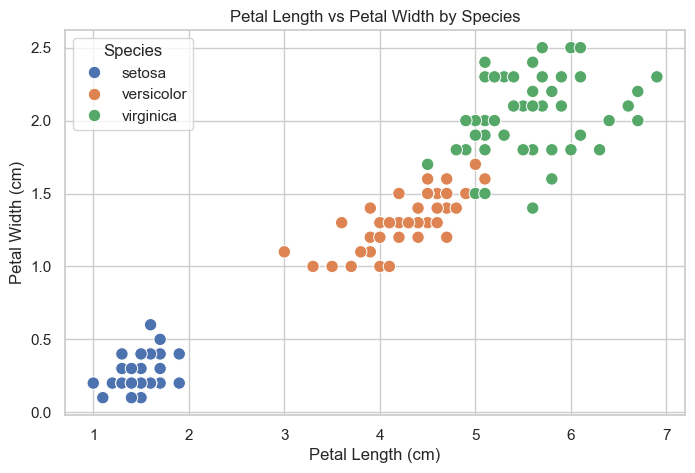

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",  # color d/f groups/clusters
    s=80  # size of the data points
)
plt.title("Petal Length vs Petal Width by Species")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend(title="Species")
plt.show()


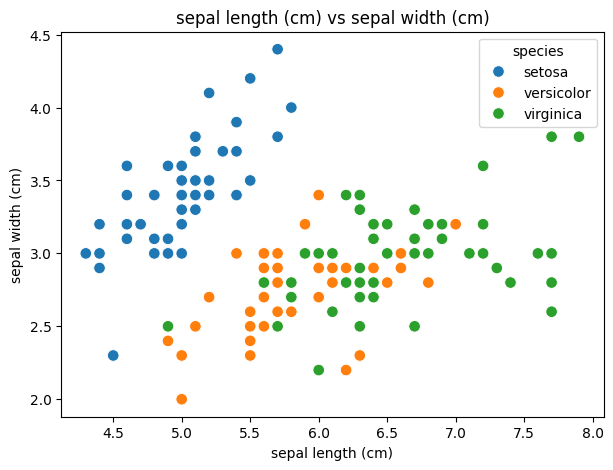

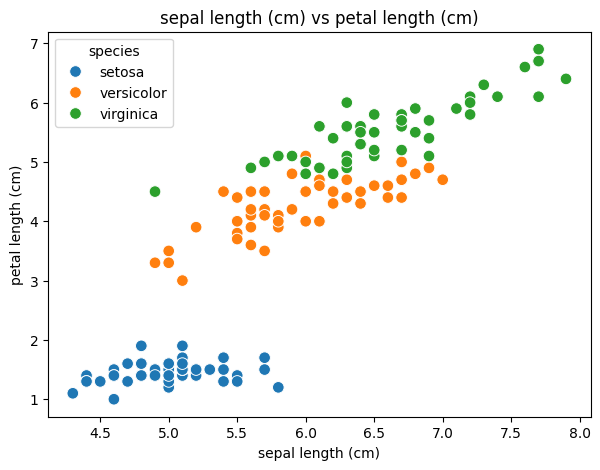

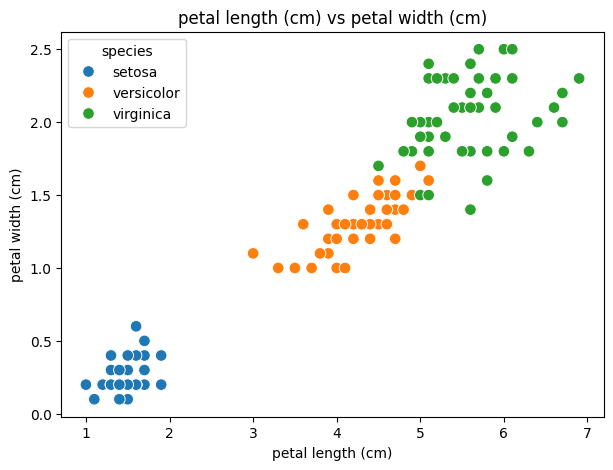

In [123]:
# Compare several meaningful feature pairs

pairs = [
    ("sepal length (cm)", "sepal width (cm)"),
    ("sepal length (cm)", "petal length (cm)"),
    ("petal length (cm)", "petal width (cm)")
]


# plt.figure(figsize=(7, 5))
for x, y in pairs:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x=x, y=y, hue="species", s=70)
    plt.title(f"{x} vs {y}")
    plt.show()


# Part C — Correlation

## 8. What Is Correlation?

Correlation measures the **strength and direction of a linear relationship** between numerical variables.

For Pearson correlation:

- approximately `+1` → strong positive linear relationship
- approximately `0` → little/no linear relationship
- approximately `-1` → strong negative linear relationship

### Note

**Correlation does not imply causation.**

A high correlation means two variables move together in a linear way. It does not prove that one causes the other.


In [ ]:
correlation_matrix = df[numerical_features].corr()
display(correlation_matrix)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


## 9. Correlation Heatmap

A heatmap gives a visual representation of the correlation matrix.

- Cell → correlation coefficient
- Color intensity → strength/direction according to the chosen colormap
- Diagonal → 1.00 because every variable is perfectly correlated with itself



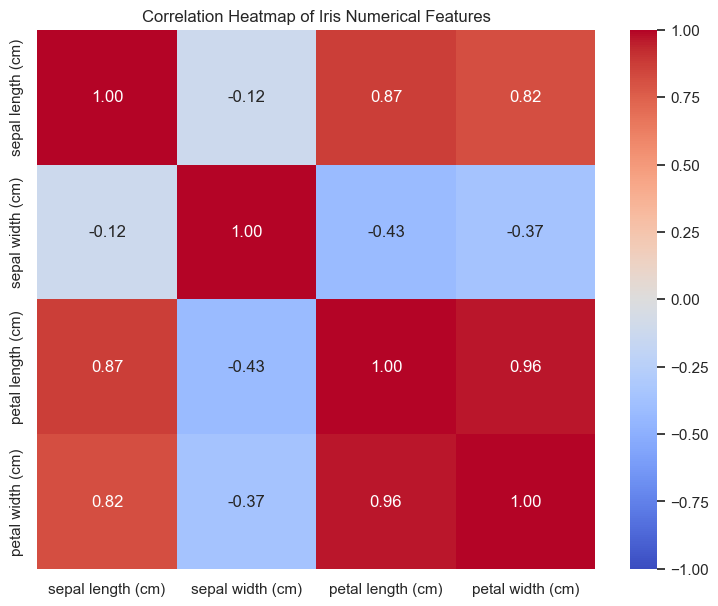

In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)
plt.title("Correlation Heatmap of Iris Numerical Features")
plt.show()




For example, a strong positive relationship between petal length and petal width means larger values of one tend to be associated with larger values of the other in this dataset.

It does **not** tell us why the relationship exists.


# Part D — Multivariate Analysis

##  Pair Plot

A pair plot lets us examine many numerical relationships at once.

- **Diagonal** → distribution of one feature
- **Off-diagonal** → relationship between two features
- **Hue/color** → species



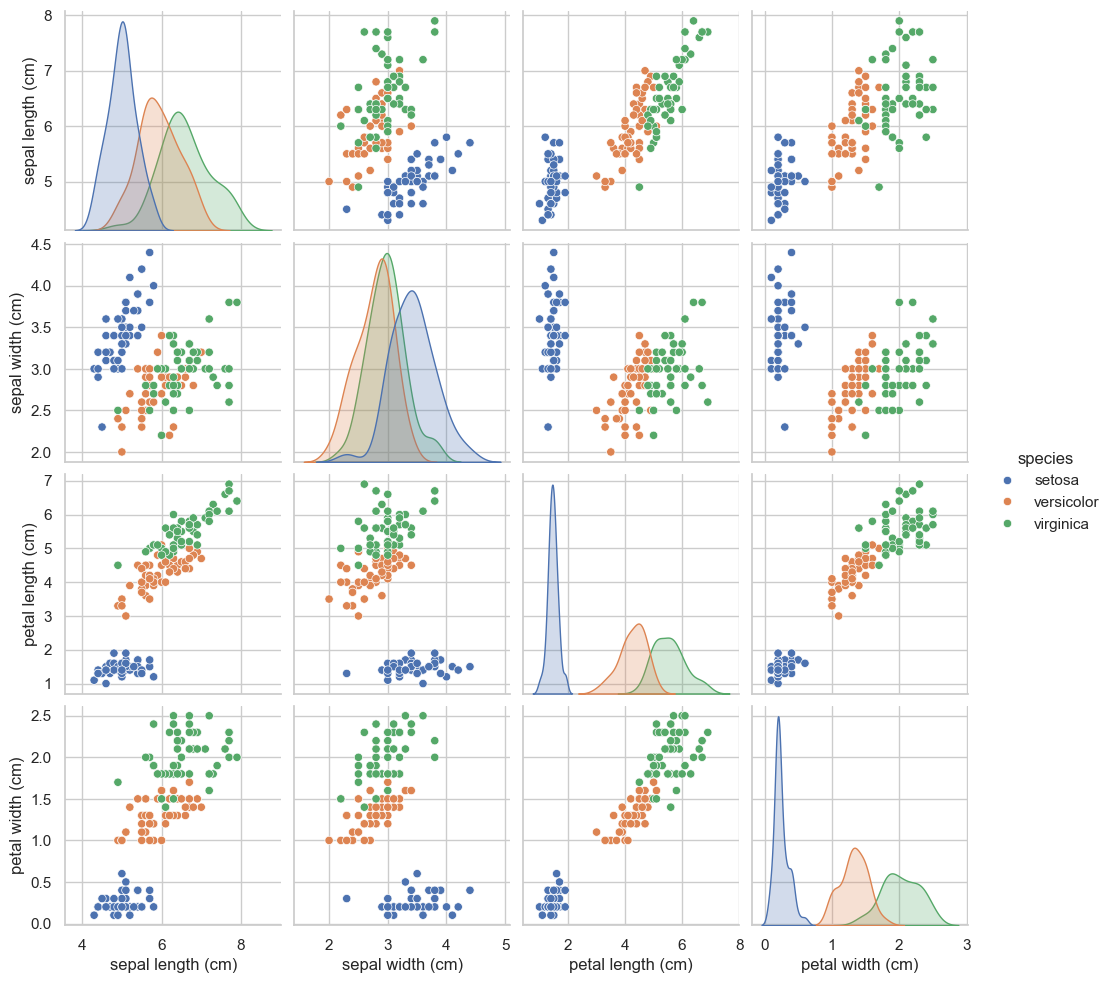

In [ ]:
sns.pairplot(
    df,
    hue="species"
)
plt.show()


# Summary Which Graph Should I Choose?

| Question | Recommended visualization |
|---|---|
| What is the distribution of one numerical variable? | Histogram |
| What is the smooth estimated distribution? | KDE |
| Are there possible outliers? | Box plot |
| How does a numerical variable differ across categories? | Box plot / Violin plot |
| How many observations are in each category? | Count plot |
| How are two numerical variables related? | Scatter plot |
| How are numerical variables correlated? | Correlation matrix / Heatmap |
| How do multiple numerical variables relate? | Pair plot |


